<a href="https://colab.research.google.com/github/komazawa-deep-learning/komazawa-deep-learning.github.io/blob/master/2026notebooks/2026HOG_SIFT_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 画像を読み込み，グレースケール化する
2. HOG 特徴量を抽出し，可視化する
3. SIFT でキーポイントと記述子を抽出する
4. HOG と SIFT の違いを確認する
5. 2 枚の画像で SIFT マッチングを行う
6. CNN への橋渡しとして，HOG/SIFT と CNN の違いを整理する

画像は Colab 上でサンプル画像を自動取得する形にしています。
授業で使う画像に差し替える場合は，`img1_path`, `img2_path` を変更すればよいです。


In [1]:
# ============================================================
# 0. ライブラリの準備
# ============================================================

# Colabでは多くの場合すでに入っているが，念のためインストール
import IPython
isColab =  'google.colab' in str(IPython.get_ipython())

if isColab:
    !pip -q install opencv-python scikit-image matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
from skimage import data
from skimage.color import rgb2gray
from skimage.io import imread
from skimage.transform import resize

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


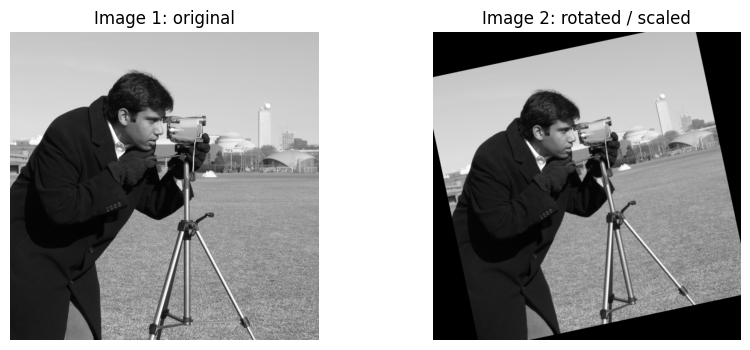

In [2]:
# ============================================================
# 1. サンプル画像の準備
# ============================================================
# ここでは skimage のサンプル画像を使う。
# 自分の画像を使う場合は，Colab 左側にアップロードしてパスを指定する。

from skimage import data

# 画像 1: カメラマン画像
img1_gray = data.camera()  # すでにグレースケール

# 画像 2: img1を少し回転・変形したものを作る（SIFTマッチング用）
h, w = img1_gray.shape
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle=12, scale=0.9)
img2_gray = cv2.warpAffine(img1_gray, M, (w, h))

# 表示
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img1_gray, cmap="gray")
plt.title("Image 1: original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2_gray, cmap="gray")
plt.title("Image 2: rotated / scaled")
plt.axis("off")

plt.show()

HOG feature vector shape: (142884,)


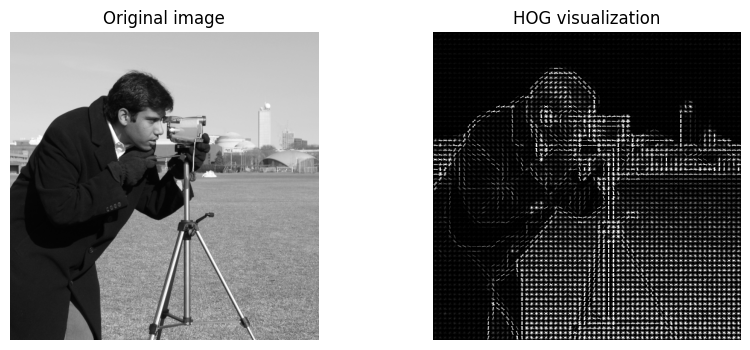

In [3]:
# ============================================================
# 2. HOG特徴量の抽出と可視化
# ============================================================
# HOG = Histogram of Oriented Gradients
# 局所領域ごとに，エッジの方向分布を集計する特徴量。

# HOG特徴量と可視化画像を取得
hog_features, hog_image = hog(
    img1_gray,
    orientations=9,              # 勾配方向を何分割するか
    pixels_per_cell=(8, 8),       # 1セルの大きさ
    cells_per_block=(2, 2),       # 正規化に使うブロックサイズ
    block_norm="L2-Hys",
    visualize=True,
    feature_vector=True
)

# HOG可視化画像のコントラストを調整
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

print("HOG feature vector shape:", hog_features.shape)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img1_gray, cmap="gray")
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image_rescaled, cmap="gray")
plt.title("HOG visualization")
plt.axis("off")

plt.show()

Number of SIFT keypoints: 791
Descriptor shape: (791, 128)


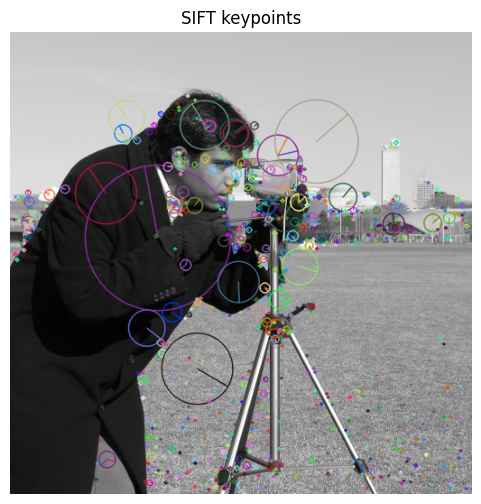

In [4]:
# ============================================================
# 3. SIFT特徴点と記述子の抽出
# ============================================================
# SIFT = Scale-Invariant Feature Transform
# 画像中の特徴的な点（keypoints）を検出し，
# その周辺の局所パターンを記述子（descriptor）として表す。

# OpenCV用に uint8 に変換
img1_cv = img1_gray.astype(np.uint8)

# SIFT detector の作成
sift = cv2.SIFT_create()

# キーポイントと記述子を抽出
keypoints1, descriptors1 = sift.detectAndCompute(img1_cv, None)

print("Number of SIFT keypoints:", len(keypoints1))
print("Descriptor shape:", descriptors1.shape)

# キーポイントを画像に描画
img1_sift = cv2.drawKeypoints(
    img1_cv,
    keypoints1,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(6, 6))
plt.imshow(img1_sift, cmap="gray")
plt.title("SIFT keypoints")
plt.axis("off")
plt.show()

In [5]:
# ============================================================
# 4. HOGとSIFTの違いを確認
# ============================================================
# HOG: 画像全体をセルに分け，勾配方向の分布を集計する。
# SIFT: 特徴的な点を検出し，各点の周辺を記述する。

print("=== HOG ===")
print("特徴の種類: 画像全体または一定領域の勾配方向ヒストグラム")
print("主な用途: 物体検出，形状特徴の記述")
print("特徴量の形:", hog_features.shape)

print("\n=== SIFT ===")
print("特徴の種類: キーポイントごとの局所記述子")
print("主な用途: 画像マッチング，対応点検出，物体認識")
print("キーポイント数:", len(keypoints1))
print("記述子の形:", descriptors1.shape)

=== HOG ===
特徴の種類: 画像全体または一定領域の勾配方向ヒストグラム
主な用途: 物体検出，形状特徴の記述
特徴量の形: (142884,)

=== SIFT ===
特徴の種類: キーポイントごとの局所記述子
主な用途: 画像マッチング，対応点検出，物体認識
キーポイント数: 791
記述子の形: (791, 128)


Image 1 keypoints: 791
Image 2 keypoints: 782
Raw matches: 791
Good matches after ratio test: 430


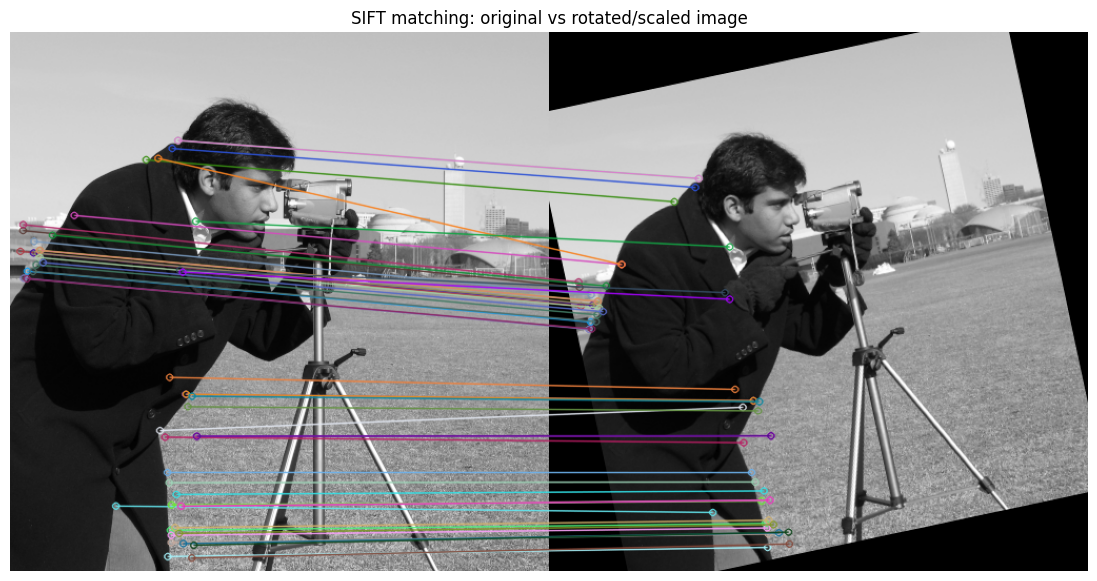

In [6]:
# ============================================================
# 5. 2枚の画像でSIFTマッチング
# ============================================================
# 画像1と画像2の間で，同じ場所に対応しそうな特徴点を探す。

img2_cv = img2_gray.astype(np.uint8)

# 画像2からもSIFT特徴を抽出
keypoints2, descriptors2 = sift.detectAndCompute(img2_cv, None)

print("Image 1 keypoints:", len(keypoints1))
print("Image 2 keypoints:", len(keypoints2))

# BFMatcherを使う
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

# k 近傍マッチング
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Lowe's ratio test
good_matches = []
ratio = 0.75

for m, n in matches:
    if m.distance < ratio * n.distance:
        good_matches.append(m)

print("Raw matches:", len(matches))
print("Good matches after ratio test:", len(good_matches))

# 良いマッチの一部を描画
matched_img = cv2.drawMatches(
    img1_cv,
    keypoints1,
    img2_cv,
    keypoints2,
    good_matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(14, 7))
plt.imshow(matched_img, cmap="gray")
plt.title("SIFT matching: original vs rotated/scaled image")
plt.axis("off")
plt.show()

In [7]:
# ============================================================
# 6. CNNへの橋渡し：HOG/SIFTとCNNの違い
# ============================================================

summary = """
HOG/SIFT と CNN の違い

HOG:
- 人間が設計した特徴量。
- 局所領域ごとにエッジ方向の分布を集計する。
- 画像全体の形状や輪郭情報を記述するのに向いている。

SIFT:
- 人間が設計した局所特徴量。
- 画像中の特徴的な点を検出し，その周辺を記述する。
- 回転やスケール変化に比較的強く，画像マッチングに向いている。

CNN:
- 特徴量を人間が設計するのではなく，データから学習する。
- 初期層ではエッジや局所パターンに反応するフィルタが学習されやすい。
- 深い層では，より複雑な形状や対象カテゴリに対応する表現が作られる。

重要な理解:
HOG/SIFT は「人間が設計した局所特徴」。
CNN は「局所特徴をデータから学習するモデル」。
したがって，HOG/SIFT は CNN を理解するための前史として位置づけられる。
"""

print(summary)


HOG/SIFT と CNN の違い

HOG:
- 人間が設計した特徴量。
- 局所領域ごとにエッジ方向の分布を集計する。
- 画像全体の形状や輪郭情報を記述するのに向いている。

SIFT:
- 人間が設計した局所特徴量。
- 画像中の特徴的な点を検出し，その周辺を記述する。
- 回転やスケール変化に比較的強く，画像マッチングに向いている。

CNN:
- 特徴量を人間が設計するのではなく，データから学習する。
- 初期層ではエッジや局所パターンに反応するフィルタが学習されやすい。
- 深い層では，より複雑な形状や対象カテゴリに対応する表現が作られる。

重要な理解:
HOG/SIFT は「人間が設計した局所特徴」。
CNN は「局所特徴をデータから学習するモデル」。
したがって，HOG/SIFT は CNN を理解するための前史として位置づけられる。



In [8]:
# 必要なら，学生用には最後に短い確認課題を付けるとよいです。

# ============================================================
# 確認課題
# ============================================================

questions = """
確認課題

1. HOG は画像のどのような情報を特徴量にしているか。
2. SIFT は HOG と比べて，どの点が異なるか。
3. SIFT マッチングでは，なぜ2枚の画像の対応点を見つけられるのか。
4. HOG/SIFT と CNN の最大の違いは何か。
5. CNN の初期層がエッジ検出器のような働きをする，と言われる理由を説明せよ。
"""

print(questions)


確認課題

1. HOG は画像のどのような情報を特徴量にしているか。
2. SIFT は HOG と比べて，どの点が異なるか。
3. SIFT マッチングでは，なぜ2枚の画像の対応点を見つけられるのか。
4. HOG/SIFT と CNN の最大の違いは何か。
5. CNN の初期層がエッジ検出器のような働きをする，と言われる理由を説明せよ。

